#Day 20 - Prediksi Harga Rumah Boston

Setelah mengenal regresi linear, kita terapkan pada kasus klasik: **memprediksi harga rumah**. Dataset Boston Housing adalah salah satu dataset regresi paling terkenal untuk belajar.

> 🎯 **Tujuan Pembelajaran**

  > - Membangun model **regresi linear multivariat** (banyak fitur).
  > - Menganalisis **korelasi fitur terhadap harga** (`MEDV`).
  > - Menafsirkan **koefisien model** dalam konteks harga rumah.
  > - Mengevaluasi dengan R²/MAE/RMSE dan membaca **residual plot**.

## Tentang Dataset

**Boston House Prices** — informasi 506 wilayah perumahan di Boston beserta median harga rumah.

- **Sumber:** [Kaggle — fedesoriano/the-boston-houseprice-data](https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data)

| Kolom (sebagian) | Arti |
|------------------|------|
| `RM` | Rata-rata jumlah kamar per rumah |
| `LSTAT` | % penduduk status ekonomi rendah |
| `CRIM` | Tingkat kriminalitas per kapita |
| `PTRATIO` | Rasio murid-guru |
| `NOX` | Konsentrasi polusi (nitrogen oksida) |
| `MEDV` | **Target**: median harga rumah (ribuan USD) |

Kita akan **memprediksi `MEDV`** dari fitur-fitur wilayah.

##Import Library

- **pandas/numpy** → olah data.
- **matplotlib/seaborn** → visualisasi.
- **scikit-learn** → split data, `LinearRegression`, metrik evaluasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

##Import Dataset

In [2]:
!pip install -q kaggle
!kaggle datasets download -d fedesoriano/the-boston-houseprice-data

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data
License(s): copyright-authors
100% 12.3k/12.3k [00:00<00:00, 21.7MB/s]



In [3]:
!unzip the-boston-houseprice-data.zip

Archive:  the-boston-houseprice-data.zip
  inflating: boston.csv              


In [5]:
df = pd.read_csv('boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


 **Interpretasi:**
 - Semua kolom numerik. `MEDV` di kolom terakhir adalah target.
 - Karena semua fitur sudah berupa angka, kita bisa langsung membangun model regresi tanpa encoding.

##Explorasi Awal

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [7]:
df.isna().sum().sum()

np.int64(0)

**Interpretasi:**
- 506 baris tanpa missing value.
- Median harga (`MEDV`) berkisar dari ~5 hingga 50
(ribuan USD), dengan rata-rata sekitar 22.
- Nilai 50 kemungkinan adalah batas atas yang dipotong (capped).

##EDA & Visualisasi

###a) Distribusi Harga Rumah

Text(0.5, 1.0, 'Distribusi Harga Rumah')

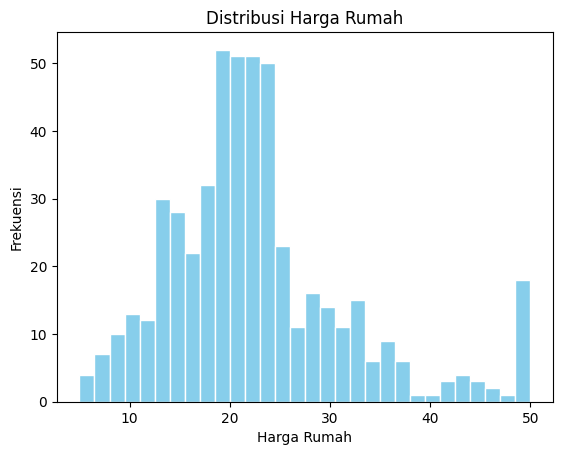

In [9]:
plt.hist(df['MEDV'], bins=30, color='skyblue',edgecolor='white')
plt.xlabel('Harga Rumah')
plt.ylabel('Frekuensi')
plt.title('Distribusi Harga Rumah')

Interpretasi:
- Distribusi sedikit ke arah kanan, dengan lonjakan di nilai 50, ada indikasi Outlier
- sebagaian besar nilai berada diharga 15-25 ribu Usd

###b) Kolerasi Harga Rumah dengan

In [12]:
corr_price = df.corr()['MEDV'].drop("MEDV").sort_values()
corr_price

,MEDV
LSTAT,-0.737663
PTRATIO,-0.507787
INDUS,-0.483725
TAX,-0.468536
NOX,-0.427321
CRIM,-0.388305
RAD,-0.381626
AGE,-0.376955
CHAS,0.175260
DIS,0.249929


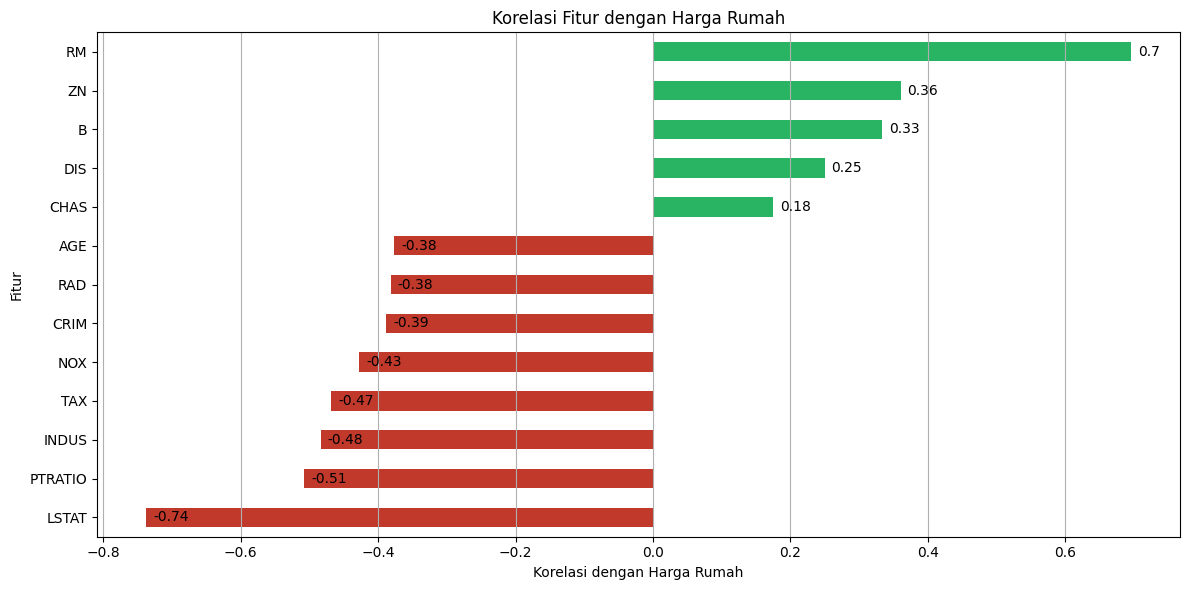

In [19]:
corr_price.plot(kind='barh',
                figsize=(12,6),
                color=["#C0392B" if v < 0 else "#28B463" for v in corr_price.values])
plt.xlabel('Korelasi dengan Harga Rumah')
plt.ylabel('Fitur')
plt.title('Korelasi Fitur dengan Harga Rumah')
plt.grid(axis='x')
plt.tight_layout()
#anotate
for i in range(len(corr_price)):
    plt.text(corr_price.values[i] + 0.01, i, round(corr_price.values[i], 2), va='center')
plt.show()

**Interpretasi:**
  - **`RM`** (jumlah kamar) berkorelasi **positif** paling kuat — makin banyak kamar,
makin mahal.
  - **`LSTAT`** (% penduduk ekonomi rendah) berkorelasi **negatif** paling kuat — makin tinggi
LSTAT, makin murah.
  - Dua fitur ini akan paling berpengaruh pada model.

###c)Scatter RM & LSTAT vs MEDV

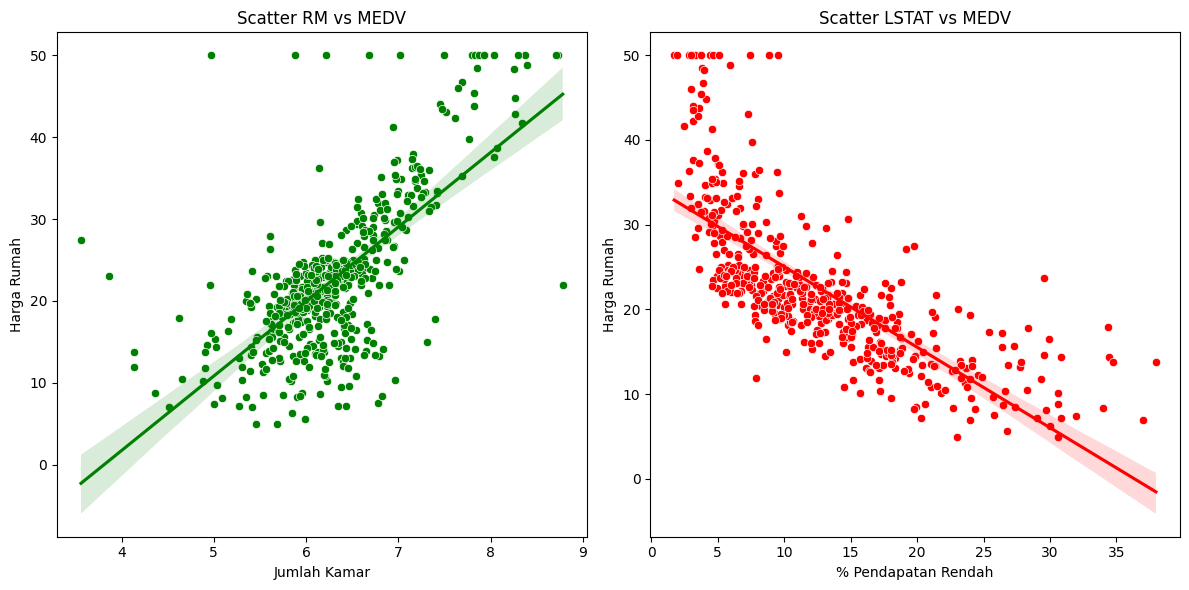

In [27]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
sns.scatterplot(x='RM', y='MEDV', data=df, ax=ax[0], color="green")
sns.regplot(x='RM', y='MEDV', data=df, ax=ax[0], scatter=False, color='green')
ax[0].set_title('Scatter RM vs MEDV')
ax[0].set_xlabel('Jumlah Kamar')
ax[0].set_ylabel('Harga Rumah')


sns.scatterplot(x='LSTAT', y='MEDV', data=df, ax=ax[1], color="red")
sns.regplot(x='LSTAT', y='MEDV', data=df, ax=ax[1], scatter=False, color='red')
ax[1].set_title('Scatter LSTAT vs MEDV')
ax[1].set_xlabel('% Pendapatan Rendah')
ax[1].set_ylabel('Harga Rumah')
plt.tight_layout()
plt.show()


**Interpretasi:**


  -  `RM` menunjukkan tren naik yang cukup linear terhadap harga.
  - `LSTAT` menunjukkan tren turun yang (non-linear) — petunjuk bahwa model linear murni mungkin tidak menangkap seluruh polanya.

## Preprocessing - Pisahkan X & y

Target kita `MEDV`, sisanya menjadi fitur. Kita bagi 80% latih / 20% uji.

In [28]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [29]:
x_train, x_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [30]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(404, 13)
(102, 13)
(404,)
(102,)


**Interpretasi:**
- Model akan belajar dari 404 wilayah dan
- diuji pada 102 wilayah yang belum pernah dilihat — ini menjamin evaluasi yang jujur.

##Modeling - Regrsi Multivariat

In [31]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

##Evaluate

### Metrik R², MAE, RMSE

In [32]:
y_pred = model.predict(x_test)

In [38]:
print(f'R2: {r2_score(y_test, y_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'Intersep: {model.intercept_:.2f}')

R2: 0.67
MAE: 3.19
RMSE: 4.93
Intersep: 30.25


Interpretasi:
  - R² = 0.67 → model mampu menjelaskan sekitar 67% variasi target, sementara 33% sisanya dipengaruhi faktor lain/error.
  - MAE = 3.19 → secara rata-rata, prediksi model melenceng sekitar 3.19 poin dari nilai aktual.
  - RMSE = 4.93 → besar error prediksi sekitar 4.93 poin, dengan penalti lebih besar terhadap error yang besar.
  - Intercept = 30.25 → ketika seluruh fitur X = 0, model memprediksi target sekitar 30.25. Interpretasinya perlu hati-hati jika X=0 tidak punya makna nyata.

Kesimpulan singkat: model sudah menangkap pola yang cukup baik (67% variasi), dengan rata-rata penyimpangan 3.19 poin, tetapi masih terdapat error yang relatif lebih besar pada beberapa observasi (RMSE 4.93).

### Koefisien Model

In [39]:
coef_model = pd.Series(model.coef_, index=x_train.columns).sort_values()
coef_model

,0
NOX,-17.202633
DIS,-1.447865
PTRATIO,-0.915456
LSTAT,-0.508571
CRIM,-0.113056
TAX,-0.010647
AGE,-0.006296
B,0.012351
ZN,0.030110
INDUS,0.040381


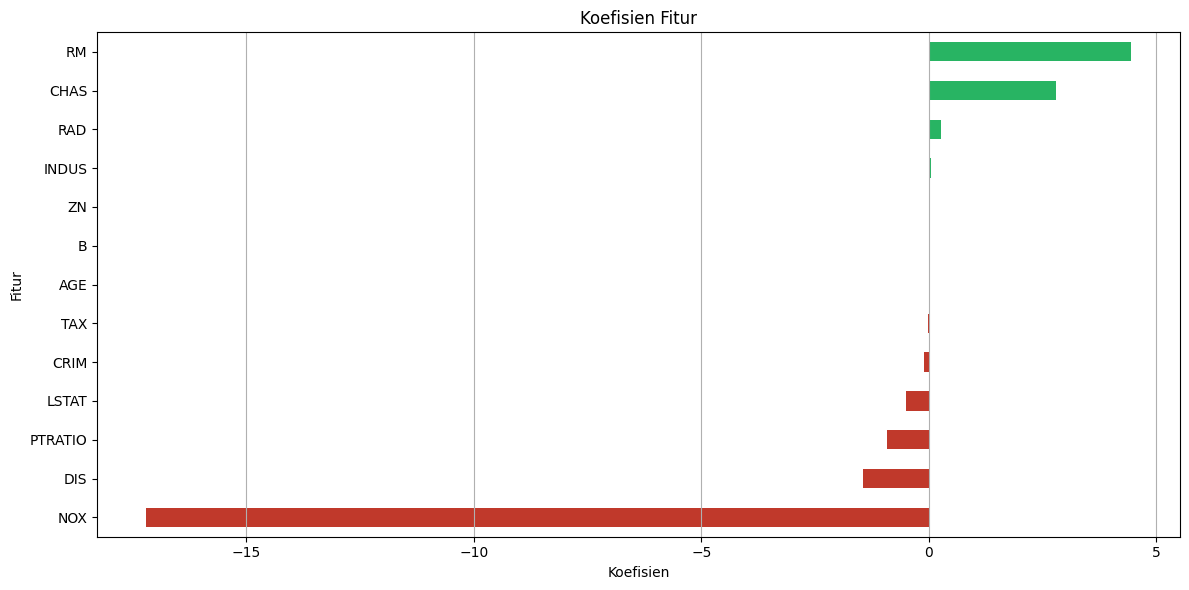

In [40]:
coef_model.plot(kind='barh',
                figsize=(12,6),
                color=["#C0392B" if v < 0 else "#28B463" for v in coef_model.values])
plt.xlabel('Koefisien')
plt.ylabel('Fitur')
plt.title('Koefisien Fitur')
plt.grid(axis='x')
plt.tight_layout()

Koefisien negatif (-)

    → ketika fitur meningkat, prediksi target cenderung turun, dengan asumsi fitur lainnya tetap.
    Contoh:
    NOX = -17.203 → kenaikan NOX berasosiasi dengan penurunan prediksi target, holding fitur lain konstan.

Koefisien positif (+)

    → ketika fitur meningkat, prediksi target cenderung naik, dengan asumsi fitur lainnya tetap.
    Contoh:
    RM = +4.439 → kenaikan RM berasosiasi dengan kenaikan prediksi target, holding fitur lain konstan.

### Prediksi vs Aktual

Text(0.5, 1.0, 'Prediksi vs Aktual')

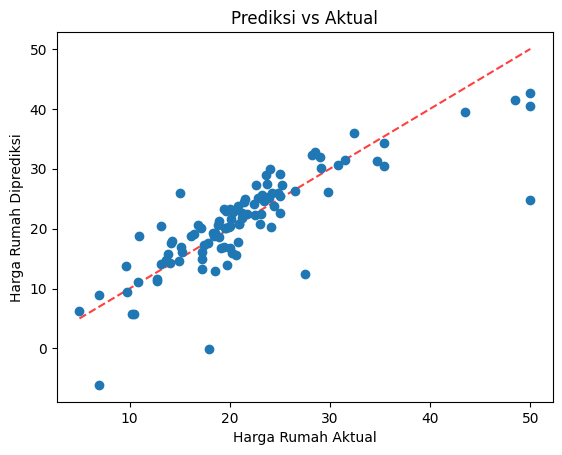

In [45]:
plt.scatter(y_test,
            y_pred)
lims = [y_test.min(),
        y_test.max()]
plt.plot(lims,
         lims,
         'r--',
         alpha=0.75,
         zorder=0)
plt.xlabel('Harga Rumah Aktual')
plt.ylabel('Harga Rumah Diprediksi')
plt.title('Prediksi vs Aktual')

Interpretasi

* **Sebagian besar titik berada cukup dekat dengan garis merah** → prediksi model cukup mengikuti nilai aktual.
* **Titik yang jauh dari garis** → menunjukkan prediksi yang error-nya lebih besar.
* Ada beberapa **outlier/penyimpangan**, misalnya aktual sekitar 18 tetapi prediksi mendekati 0.
* Secara keseluruhan, terlihat **pola positif yang cukup jelas**: semakin tinggi nilai aktual, prediksi model cenderung ikut meningkat.

Jadi secara visual, **model sudah menangkap pola hubungan target dengan cukup baik, tetapi masih ada beberapa prediksi yang melenceng cukup jauh.**


### Residual Plot

In [46]:
residual = y_test - y_pred

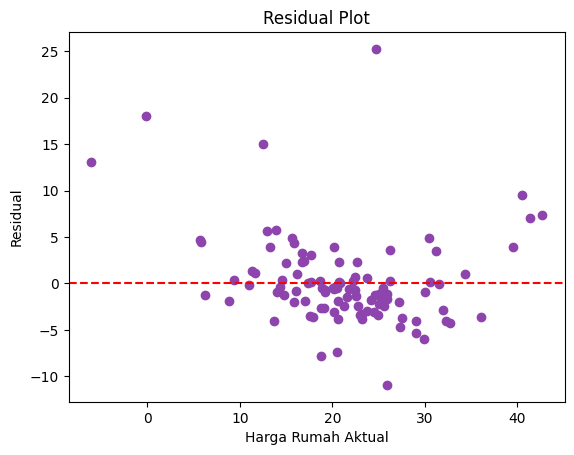

In [49]:
plt.scatter(y_pred,
            residual,
            color="#8E44AD")
plt.xlabel('Harga Rumah Aktual')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

**Interpretasi:**
- Residual sebagian besar tersebar di sekitar nol, namun terlihat pola melengkung di ujung — pertanda hubungan harga tidak sepenuhnya linear.
- Model non-linear bisa menangkap pola ini lebih baik.

## Kesimpulan dan Insight

- Regresi linear multivariat menjelaskan ~67% variasi harga rumah Boston (R² ≈ 0,67).
- **Jumlah kamar (`RM`)** menaikkan harga; **kemiskinan lingkungan (`LSTAT`)** dan **polusi (`NOX`)** menurunkannya.
- Model cenderung meleset di rumah termahal (harga yang dipotong di 50).
- **Residual plot** mengungkap pola non-linear yang tak tertangkap model linear.

Insight bisnis: untuk menaksir harga properti, **jumlah kamar dan kualitas lingkungan** adalah faktor
kunci. Untuk akurasi lebih tinggi, model non-linear (Tree/Random Forest di notebook berikutnya) layak dicoba.